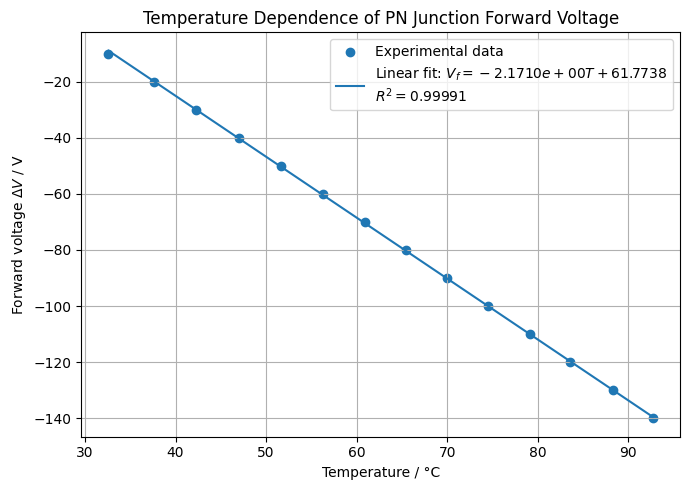

Slope k = -2.171012e+00 V/temperature_unit
Intercept b = 61.773774 V
R^2 = 0.999906


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 输入实验数据
# =========================
# 温度，单位可为 ℃ 或 K
T = np.array([32.6, 37.6, 42.3, 47.0, 51.6, 56.3, 60.9, 65.5, 70.0, 74.5, 79.1, 83.6, 88.3, 92.7
    # 在这里填入温度数据
    
], dtype=float)

# PN结正向压降，单位通常为 V
Vf_list = range(-10,-150,-10)
Vf = np.array( Vf_list
    # 在这里填入对应的正向压降数据
, dtype=float)

# =========================
# 2. 线性拟合
# =========================
# 拟合形式：Vf = k*T + b
k, b = np.polyfit(T, Vf, deg=1)

# 生成用于绘制拟合直线的横坐标
T_fit = np.linspace(T.min(), T.max(), 200)
Vf_fit = k * T_fit + b

# =========================
# 3. 计算拟合优度 R^2
# =========================
Vf_pred = k * T + b
ss_res = np.sum((Vf - Vf_pred) ** 2)
ss_tot = np.sum((Vf - np.mean(Vf)) ** 2)
r_squared = 1 - ss_res / ss_tot

# =========================
# 4. 绘图
# =========================
plt.figure(figsize=(7, 5))

plt.scatter(T, Vf, label='Experimental data')
plt.plot(
    T_fit,
    Vf_fit,
    label=f'Linear fit: $V_f = {k:.4e}T + {b:.4f}$\n$R^2 = {r_squared:.5f}$'
)

plt.xlabel('Temperature / °C')
plt.ylabel('Forward voltage $\Delta V$ / V')
plt.title('Temperature Dependence of PN Junction Forward Voltage')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# =========================
# 5. 输出拟合结果
# =========================
print(f"Slope k = {k:.6e} V/temperature_unit")
print(f"Intercept b = {b:.6f} V")
print(f"R^2 = {r_squared:.6f}")

In [2]:
import numpy as np
Vf_list = range(-10,-150,-10)
Vf = np.array( Vf_list
    # 在这里填入对应的正向压降数据
, dtype=float)
print(Vf)

[ -10.  -20.  -30.  -40.  -50.  -60.  -70.  -80.  -90. -100. -110. -120.
 -130. -140.]


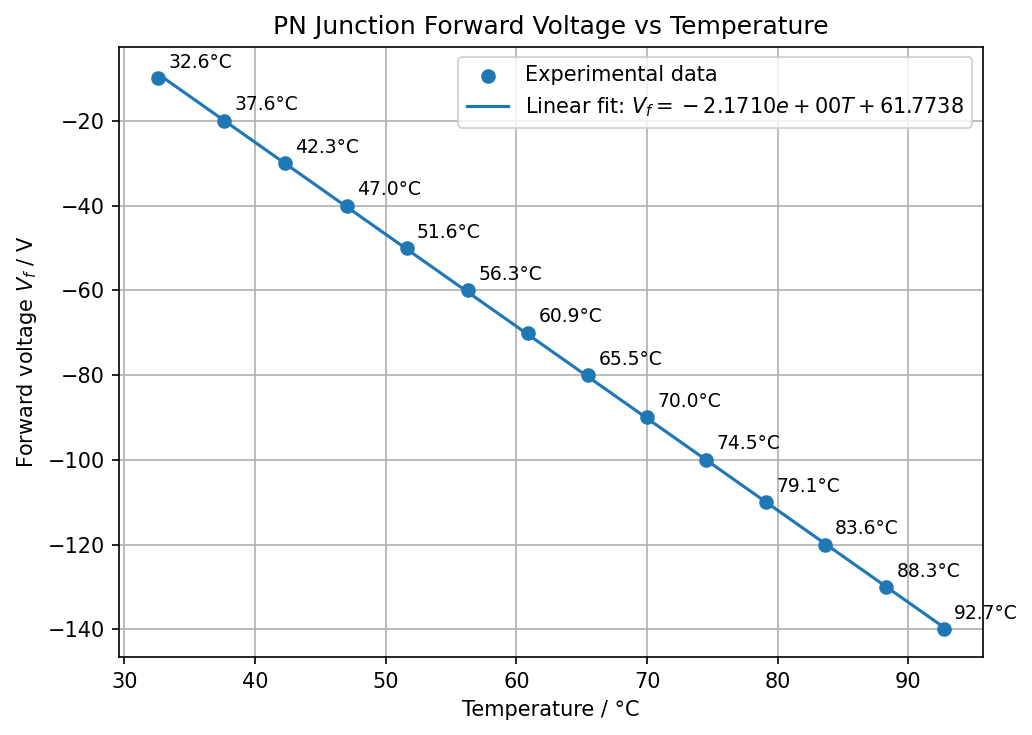

图片已保存为 pn_junction_voltage_temperature_fit.png
拟合斜率 k = -2.171012e+00 V/°C
截距 b = 61.773774 V


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 输入实验数据
# =========================
# 温度，单位可为 
T = np.array([32.6, 37.6, 42.3, 47.0, 51.6, 56.3, 60.9, 65.5, 70.0, 74.5, 79.1, 83.6, 88.3, 92.7
    # 在这里填入温度数据
    
], dtype=float)

# PN结正向压降，单位通常为 V
Vf_list = range(-10,-150,-10)
Vf = np.array( Vf_list
    # 在这里填入对应的正向压降数据
, dtype=float)
# =========================
# 2. 线性拟合
# =========================
k, b = np.polyfit(T, Vf, deg=1)

T_fit = np.linspace(T.min(), T.max(), 200)
Vf_fit = k * T_fit + b

# =========================
# 3. 绘图
# =========================
plt.figure(figsize=(7, 5), dpi=150)

plt.scatter(T, Vf, label='Experimental data', zorder=3)

plt.plot(
    T_fit,
    Vf_fit,
    label=f'Linear fit: $V_f = {k:.4e}T + {b:.4f}$'
)

# =========================
# 4. 标注每个数据点的温度值
# =========================
for t, v in zip(T, Vf):
    plt.annotate(
        f'{t:.1f}°C',          # 显示温度值
        xy=(t, v),             # 数据点位置
        xytext=(5, 5),         # 文字相对数据点的偏移，单位是 points
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Temperature / °C')
plt.ylabel('Forward voltage $V_f$ / V')
plt.title('PN Junction Forward Voltage vs Temperature')
plt.legend()
plt.grid(True)
plt.tight_layout()

# =========================
# 5. 导出图片
# =========================
plt.savefig(
    'pn_junction_voltage_temperature_fit.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"图片已保存为 pn_junction_voltage_temperature_fit.png")
print(f"拟合斜率 k = {k:.6e} V/°C")
print(f"截距 b = {b:.6f} V")